# COS30082 - Metric Learning Model

> Aston Lynch - 103964552

## 1. Imports and Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import tensorflow as tf
import keras as tfk
from keras import layers as tkl
from sklearn.metrics import roc_auc_score, roc_curve
import random

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

I0000 00:00:1777864047.403169  225867 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777864047.432519  225867 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777864048.300319  225867 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
IMG_SIZE = (96, 96)
IMG_SHAPE = IMG_SIZE + (3,)
BATCH_SIZE = 64
EMBEDDING_DIM = 128
LEARNING_RATE = 1e-4
MARGIN = 0.2
EPOCHS = 50
DATA_DIR = '../data/classification_data'

## 2. Data Loading

In [3]:
preprocess_input = tfk.applications.mobilenet_v2.preprocess_input

def load_image(path):
    img = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
    img = tf.keras.utils.img_to_array(img)
    return preprocess_input(img)

def build_identity_map(split):
    identity_map = {}
    split_dir = os.path.join(DATA_DIR, split)
    for identity in sorted(os.listdir(split_dir)):
        identity_dir = os.path.join(split_dir, identity)
        images = [
            os.path.join(identity_dir, f)
            for f in os.listdir(identity_dir)
            if f.endswith('.jpg')
        ]
        if len(images) >= 2:
            identity_map[identity] = images
    return identity_map

train_map = build_identity_map('train_data')
identities = list(train_map.keys())

print(f"Identities with ≥2 images: {len(identities)}")
print(f"Example identity image count: {len(train_map[identities[0]])}")

Identities with ≥2 images: 4000
Example identity image count: 41


## 3. Triplet Generator

In [4]:
def generate_triplets(identity_map, identities, num_triplets):
    anchors, positives, negatives = [], [], []

    for _ in range(num_triplets):
        anchor_id = random.choice(identities)
        anchor_path, positive_path = random.sample(identity_map[anchor_id], 2)

        negative_id = random.choice(identities)
        while negative_id == anchor_id:
            negative_id = random.choice(identities)
        negative_path = random.choice(identity_map[negative_id])

        anchors.append(load_image(anchor_path))
        positives.append(load_image(positive_path))
        negatives.append(load_image(negative_path))

    return np.array(anchors), np.array(positives), np.array(negatives)

## 4. Model Building

In [5]:
base_model = tfk.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False
for layer in base_model.layers[-11:]:
    layer.trainable = True

inputs = tfk.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = tkl.GlobalAveragePooling2D()(x)
x = tkl.Dropout(0.3)(x)
x = tkl.Dense(EMBEDDING_DIM, activation='linear', name='embedding')(x)
embedding_model = tfk.Model(inputs, x, name='embedding_model')

anchor_input = tfk.Input(shape=IMG_SHAPE, name='anchor')
positive_input = tfk.Input(shape=IMG_SHAPE, name='positive')
negative_input = tfk.Input(shape=IMG_SHAPE, name='negative')

anchor_emb = embedding_model(anchor_input)
positive_emb = embedding_model(positive_input)
negative_emb = embedding_model(negative_input)

triplet_model = tfk.Model(
    inputs=[anchor_input, positive_input, negative_input],
    outputs=[anchor_emb, positive_emb, negative_emb],
    name='triplet_model'
)

embedding_model.summary()

I0000 00:00:1777864054.189040  225867 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1123 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │       163,968 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,421,952 (9.24 MB)

 Trainable params: 1,050,048 (4.01 MB)

 Non-trainable params: 1,371,904 (5.23 MB)

## 5. Triplet Loss and Training

In [6]:
def triplet_loss(anchor, positive, negative, margin=MARGIN):
    pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=-1)
    neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=-1)
    loss = tf.maximum(pos_dist - neg_dist + margin, 0.0)
    return tf.reduce_mean(loss)

optimizer = tfk.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0)

@tf.function
def train_step(anchors, positives, negatives):
    with tf.GradientTape() as tape:
        anc_emb, pos_emb, neg_emb = triplet_model(
            [anchors, positives, negatives], training=True
        )
        loss = triplet_loss(anc_emb, pos_emb, neg_emb)
    gradients = tape.gradient(loss, triplet_model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, triplet_model.trainable_variables))
    return loss

TRIPLETS_PER_EPOCH = 10000
STEPS_PER_EPOCH = TRIPLETS_PER_EPOCH // BATCH_SIZE

os.makedirs('../checkpoints', exist_ok=True)
history = []
best_loss = float('inf')
patience_counter = 0
PATIENCE = 5

start = time.time()
for epoch in range(EPOCHS):
      epoch_losses = []

      for step in range(STEPS_PER_EPOCH):
          a, p, n = generate_triplets(train_map, identities, BATCH_SIZE)
          loss = train_step(a, p, n).numpy()
          epoch_losses.append(loss)

      mean_loss = np.mean(epoch_losses)
      history.append(mean_loss)
      print(f"Epoch {epoch+1}/{EPOCHS} — loss: {mean_loss:.4f}")

      if mean_loss < best_loss:
          best_loss = mean_loss
          patience_counter = 0
          embedding_model.save('../checkpoints/metric_best.keras')
      else:
          patience_counter += 1
          if patience_counter >= PATIENCE:
              print(f"Early stopping at epoch {epoch+1}")
              break

print(f"Training time: {time.time() - start:.1f}s")

I0000 00:00:1777864061.280379  226737 cuda_dnn.cc:461] Loaded cuDNN version 92101


Epoch 1/50 — loss: 17.2313
Epoch 2/50 — loss: 12.0753
Epoch 3/50 — loss: 9.4606
Epoch 4/50 — loss: 6.7947
Epoch 5/50 — loss: 4.8248
Epoch 6/50 — loss: 3.4750
Epoch 7/50 — loss: 2.5195
Epoch 8/50 — loss: 1.6386
Epoch 9/50 — loss: 1.1795
Epoch 10/50 — loss: 0.7977
Epoch 11/50 — loss: 0.5349
Epoch 12/50 — loss: 0.3471
Epoch 13/50 — loss: 0.2530
Epoch 14/50 — loss: 0.1869
Epoch 15/50 — loss: 0.1682
Epoch 16/50 — loss: 0.1396
Epoch 17/50 — loss: 0.1281
Epoch 18/50 — loss: 0.1153
Epoch 19/50 — loss: 0.1088
Epoch 20/50 — loss: 0.1097
Epoch 21/50 — loss: 0.1051
Epoch 22/50 — loss: 0.1025
Epoch 23/50 — loss: 0.1045
Epoch 24/50 — loss: 0.0957
Epoch 25/50 — loss: 0.1002
Epoch 26/50 — loss: 0.0968
Epoch 27/50 — loss: 0.0944
Epoch 28/50 — loss: 0.0953
Epoch 29/50 — loss: 0.0946
Epoch 30/50 — loss: 0.0913
Epoch 31/50 — loss: 0.0899
Epoch 32/50 — loss: 0.0919
Epoch 33/50 — loss: 0.0892
Epoch 34/50 — loss: 0.0893
Epoch 35/50 — loss: 0.0885
Epoch 36/50 — loss: 0.0877
Epoch 37/50 — loss: 0.0848
Epoch 38

## 6. Plot

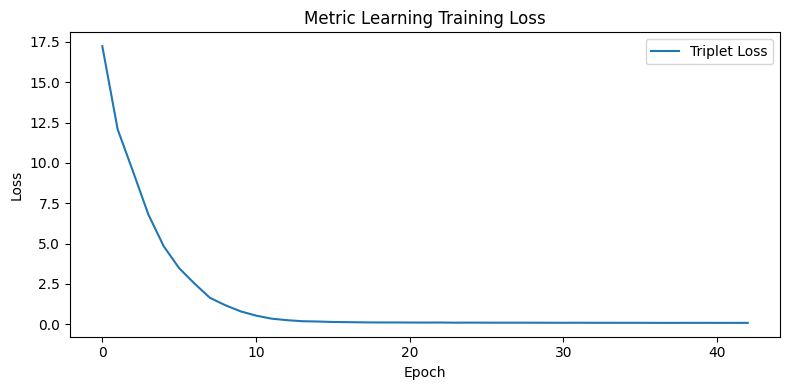

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(history, label='Triplet Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Metric Learning Training Loss')
plt.legend()
plt.tight_layout()
plt.show()